In [1]:
import numpy as np

from scipy.special import comb as n_choose_k
from sklearn.linear_model import LogisticRegression
from scipy.stats import pearsonr, spearmanr
from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
simplefilter("ignore", category=ConvergenceWarning)


import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm

from itertools import combinations
from collections import defaultdict
import random

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda')
device

device(type='cuda')

In [116]:
# Parameters
seed = 7012025
C = np.inf # no regularisation for lin. regression
power = 1 # uniform density
D = 1000 # number of data samples
N = 100 # number of sources
K = 10 # sparsity
num_ood = N // 2 # how many new OOD sources
M = int(np.ceil(K * np.log(N / K) * 1)) # Compressed Sensing bound
num_ood, M

(50, 24)

# Game Plan

### IID means either:

a) first index and any of the IID distractors [cow and grass]

b) NOT the first index and ANY of the distractors [grass and sand]

### OOD means:

c) first index and any of the OOD distractors [cow and sand]

In [97]:
# sampling functions

def sample_comb(ind, N=N, K=K, power=power):
    """given K indices, sample sources"""
    z = np.zeros(N)
    z[ind] = np.random.uniform(0, 1, K) ** power
    return z

def sample_setting_a(seed=None, N=N, K=K, num_ood=num_ood):
    """include first index and sample randomly from IID"""
    if seed is not None:
        np.random.seed(seed)
    ind_distractors = np.random.choice(
        np.arange(1, N - num_ood), K - 1, replace=False)
    # add first latent
    ind = np.concatenate([np.zeros(1, dtype=int), ind_distractors])
    z = sample_comb(ind, N=N, K=K)
    return z

def sample_setting_b(seed=None, N=N, K=K, num_ood=num_ood):
    """sample randomly from all but first"""
    if seed is not None:
        np.random.seed(seed)
    ind = np.random.choice(np.arange(1, N), K, replace=False)
    z = sample_comb(ind, N=N, K=K)
    return z

def sample_setting_c(seed=None, N=N, K=K, num_ood=num_ood):
    """include first index and sample randomly from OOD"""
    if seed is not None:
        np.random.seed(seed)
    ind_distractors = np.random.choice(
        np.arange(N - num_ood, N), K - 1, replace=False)
    # add first latent
    ind = np.concatenate([np.zeros(1, dtype=int), ind_distractors])
    z = sample_comb(ind, N=N, K=K)
    return z

def sample_iid(seed=None, N=N, K=K, num_ood=num_ood):
    """only sample from IID latent combinations"""
    if seed is not None:
        np.random.seed(seed)
    # is variable of interest in sample?
    first_one_in = np.random.binomial(n=1, p=.5)
    if first_one_in: # a) setting
        return sample_setting_a(seed=None, N=N, K=K, num_ood=num_ood)
    else: # b) setting
        return sample_setting_b(seed=None, N=N, K=K, num_ood=num_ood)

def sample_ood(seed=None, N=N, K=K, num_ood=num_ood):
    return sample_setting_c(seed=None, N=N, K=K, num_ood=num_ood)

def sample_all(seed=None, N=N, K=K):
    """no IID/OOD split, just sample all"""
    if seed is not None:
        np.random.seed(seed)
    ind = np.random.choice(np.arange(N), K, replace=False)
    z = sample_comb(ind, N=N, K=K)
    return z

In [100]:
sample_setting_c()

array([0.96811231, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.00235351, 0.        , 0.        , 0.        , 0.        ,
       0.0922974 , 0.69518073, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.1705162 , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.53357

In [101]:
# Full example: train encoder with matrix A...

In [183]:
# lazy example (might not be perfect), just draw random A
np.random.seed(seed)
# https://en.wikipedia.org/wiki/Restricted_isometry_property
A = np.random.normal(0, 1, (M, N)) # random normal has RIP -> CS works =)
A /= np.linalg.norm(A, axis=0, keepdims=True)
A.min(), A.max(), A.shape

(-0.6458119825139067, 0.6527911931680838, (24, 100))

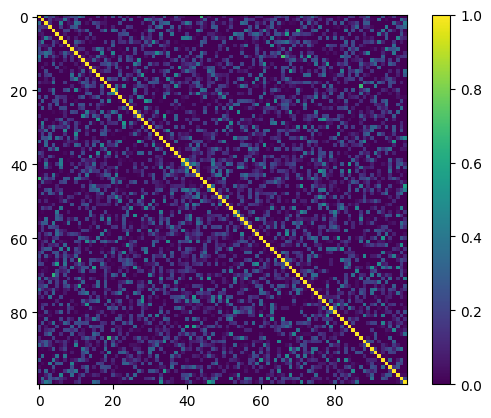

In [184]:
plt.imshow(A.T @ A, vmin=0, vmax=1, cmap='viridis')
plt.colorbar()

In [185]:
# generate data
np.random.seed(seed)

Z_iid = np.array([sample_iid() for _ in range(D)])
Y_iid = Z_iid @ A.T
label_iid = Z_iid[:, 0] > .5

Z_ood = np.array([sample_ood() for _ in range(D)])
Y_ood = Z_ood @ A.T
label_ood = Z_ood[:, 0] > .5

Z_iid.shape, Y_iid.shape, label_iid[:10], np.mean(label_iid)

((1000, 100),
 (1000, 24),
 array([False, False, False, False, False, False,  True, False, False,
        False]),
 0.237)

In [186]:
# test linear probe
clf = LogisticRegression(C=C).fit(Z_iid, label_iid)

acc_iid = clf.score(Z_iid, label_iid)
acc_ood = clf.score(Z_ood, label_ood)
print(f'In source (Z) space: acc IID: {acc_iid:.3f}, acc OOD: {acc_ood:.3f}')

clf = LogisticRegression(C=C).fit(Y_iid, label_iid)

acc_iid = clf.score(Y_iid, label_iid)
acc_ood = clf.score(Y_ood, label_ood)
print(f'In observation (Y=AZ) space: acc IID: {acc_iid:.3f}, acc OOD: {acc_ood:.3f}')

In source (Z) space: acc IID: 1.000, acc OOD: 0.950
In observation (Y=AZ) space: acc IID: 0.889, acc OOD: 0.596


In [176]:
# SAE setting
# train SAE to go from Y back to estimated/reconstructed sources Z_
# On Z_, train linear classifier - how good?

In [ ]:
# Sparse code (supervised) setting
# given matrix A, infer Z_
# On Z_, train linear classifier - how good?

In [177]:
# Sparse code (unsupervised) setting
# learn both matrix A and Z_
# On Z_, train linear classifier - how good?